# HW 16: NLP+LSTM. 32 features

In [1]:
import re
import logging
import time

from bs4 import BeautifulSoup
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm_notebook

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Embedding,
    LSTM,
    GRU,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.datasets import imdb
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import get_file
import pickle
from tqdm.notebook import tqdm

In [3]:
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

In [4]:
def plot_history(history):
    history_dict = history.history
    loss_values = history_dict['loss']
    val_loss_values = history_dict['val_loss']
    epochs = range(1, len(loss_values) + 1)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    ax1.plot(epochs, loss_values, 'bo',
             label='Training loss')
    ax1.plot(epochs, val_loss_values, 'b',
             label='Validation loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_xscale('log')

    acc_values = history_dict['accuracy']
    val_acc_values = history_dict['val_accuracy']

    ax2.plot(epochs, acc_values, 'bo',
             label='Training acc')
    ax2.plot(epochs, val_acc_values, 'b',
             label='Validation acc')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.set_xscale('log')


    plt.legend()
    plt.show()

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
%load_ext pycodestyle_magic

In [7]:
logging.basicConfig(format='%(asctime)s :\
                    %(levelname)s : %(message)s', level=logging.INFO)
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/anton/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/anton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Import data

Getting the keras imdb dataset and converting it back to actual words

In [8]:
imdb = tf.keras.datasets.imdb
(train_data, train_labels), (test_data, test_labels) =\
    imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for
                           (key, value) in word_index.items()])

In [9]:
train_reviews = [' '.join([reverse_word_index.get(i-3, "?")
                           for i in t]) for t in tqdm(train_data)]

In [10]:
test_reviews = [' '.join([reverse_word_index.get(i-3, "?")
                          for i in t]) for t in tqdm(test_data)]

In [11]:
train_data = pd.DataFrame(np.array(train_reviews),
                          columns=['review'], index=range(len(train_reviews)))
train_data['sentiment'] = train_labels
train_data.head()

,review,sentiment
0,? this film was just brilliant casting locatio...,1
1,? big hair big boobs bad music and a giant saf...,0
2,? this has to be one of the worst films of the...,0
3,? the ? ? at storytelling the traditional sort...,1
4,? worst mistake of my life br br i picked this...,0


In [12]:
test_data = pd.DataFrame(np.array(test_reviews),
                         columns=['review'])
test_data['sentiment'] = test_labels
test_data.head()

,review,sentiment
0,? please give this one a miss br br ? ? and th...,0
1,? this film requires a lot of patience because...,1
2,? many animation buffs consider ? ? the great ...,1
3,? i generally love this type of movie however ...,0
4,? like some other people wrote i'm a die hard ...,1


In [13]:
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')

In [14]:
wordnet_lemmatizer = WordNetLemmatizer()

### Helper functions

In [15]:
def series_to_wordlist(series, remove_stopwords=False):

    train_text0 = series.apply(lambda text:
                               BeautifulSoup(text, 'html.parser').get_text())
    train_text0 = train_text0.str.replace("[^a-zA-Z]", " ").str.lower()
    train_words = train_text0.str.split()

    if remove_stopwords:
        stops = set(stopwords.words("english"))
        train_words = train_words.apply(lambda text:
                                        [wordnet_lemmatizer.lemmatize(t, 'v')
                                         for t in text if t not in stops])
    else:
        train_words = train_words.apply(lambda text:
                                        [wordnet_lemmatizer.lemmatize(t, 'v')
                                         for t in text])

    return train_words.values.ravel()

In [16]:
def series_to_sentences(series, remove_stopwords=False):

    train_text = series.apply(lambda text:
                              BeautifulSoup(text, 'html.parser').get_text())
    train_tokenize = train_text.str.strip().apply(tokenizer.tokenize)

    tt_df = pd.DataFrame(train_tokenize.values.tolist())
    tt_df = tt_df.replace("[^a-zA-Z]", " ", regex=True)
    tt_df = tt_df.applymap(lambda x: x.lower() if pd.notnull(x) else '')
    stops = set(stopwords.words("english"))

    if remove_stopwords:
        tt_df = tt_df.applymap(lambda x: [wordnet_lemmatizer.lemmatize(t, 'v')
                                          for t in x.split()
                                          if t not in stops])
    else:
        tt_df = tt_df.applymap(lambda x: [wordnet_lemmatizer.lemmatize(t, 'v')
                                          for t in x.split()])

    idx = [x != [] for x in tt_df.values.ravel()]
    return tt_df.values.ravel()[idx]

In [17]:
%%time
print('Parsing sentences from training set')
sentences = series_to_sentences(train_data['review'])

Parsing sentences from training set
CPU times: user 1min 7s, sys: 797 ms, total: 1min 8s
Wall time: 1min 8s


In [18]:
all_sentences = sentences

In [19]:
print(all_sentences[0])

['this', 'film', 'be', 'just', 'brilliant', 'cast', 'location', 'scenery', 'story', 'direction', 'everyone', 's', 'really', 'suit', 'the', 'part', 'they', 'play', 'and', 'you', 'could', 'just', 'imagine', 'be', 'there', 'robert']


### Defining the Word2Vec parameters

In [20]:
num_features = 32                  
min_word_count = 40        
num_workers = 8
context = 10                                                                                   
downsampling = 1e-4

Training the model

In [21]:
# Initialize and train the model (this will take some time)
print("Training model...")
model = Word2Vec(
    all_sentences,
    workers=8,
    size=num_features,
    min_count=min_word_count,
    window=context,
    sample=downsampling,
    seed=42
)

2019-12-05 14:26:37,703 :                    INFO : collecting all words and their counts
2019-12-05 14:26:37,703 :                    INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2019-12-05 14:26:37,746 :                    INFO : PROGRESS: at sentence #10000, processed 166536 words, keeping 6492 word types
2019-12-05 14:26:37,779 :                    INFO : PROGRESS: at sentence #20000, processed 342739 words, keeping 7289 word types
2019-12-05 14:26:37,816 :                    INFO : PROGRESS: at sentence #30000, processed 508010 words, keeping 7545 word types
2019-12-05 14:26:37,857 :                    INFO : PROGRESS: at sentence #40000, processed 682510 words, keeping 7632 word types


Training model...


2019-12-05 14:26:37,891 :                    INFO : PROGRESS: at sentence #50000, processed 856794 words, keeping 7666 word types
2019-12-05 14:26:37,936 :                    INFO : PROGRESS: at sentence #60000, processed 1030291 words, keeping 7680 word types
2019-12-05 14:26:37,979 :                    INFO : PROGRESS: at sentence #70000, processed 1201078 words, keeping 7685 word types
2019-12-05 14:26:38,018 :                    INFO : PROGRESS: at sentence #80000, processed 1376792 words, keeping 7686 word types
2019-12-05 14:26:38,049 :                    INFO : PROGRESS: at sentence #90000, processed 1550921 words, keeping 7687 word types
2019-12-05 14:26:38,092 :                    INFO : PROGRESS: at sentence #100000, processed 1718983 words, keeping 7687 word types
2019-12-05 14:26:38,133 :                    INFO : PROGRESS: at sentence #110000, processed 1893836 words, keeping 7687 word types
2019-12-05 14:26:38,174 :                    INFO : PROGRESS: at sentence #120000,

2019-12-05 14:26:46,596 :                    INFO : worker thread finished; awaiting finish of 2 more threads
2019-12-05 14:26:46,598 :                    INFO : worker thread finished; awaiting finish of 1 more threads
2019-12-05 14:26:46,600 :                    INFO : worker thread finished; awaiting finish of 0 more threads
2019-12-05 14:26:46,601 :                    INFO : EPOCH - 3 : training on 5661152 raw words (2321730 effective words) took 2.5s, 930313 effective words/s
2019-12-05 14:26:47,614 :                    INFO : EPOCH 4 - PROGRESS: at 40.45% examples, 932600 words/s, in_qsize 15, out_qsize 0
2019-12-05 14:26:48,614 :                    INFO : EPOCH 4 - PROGRESS: at 81.86% examples, 948959 words/s, in_qsize 16, out_qsize 1
2019-12-05 14:26:49,029 :                    INFO : worker thread finished; awaiting finish of 7 more threads
2019-12-05 14:26:49,036 :                    INFO : worker thread finished; awaiting finish of 6 more threads
2019-12-05 14:26:49,038 :   

In [22]:
model.wv.vectors.shape

(6506, 32)

### Classifying averaged vectors with random forest as a baseline

Calculating average vector for each review:

In [23]:
def avg_vec(reviews, model, num_features):
    index2word_set = set(model.wv.index2word)
    t_df = pd.DataFrame(reviews).applymap(lambda t:
                                          [(model[x]) if x in index2word_set
                                           else np.full(num_features, np.nan)
                                           for x in t])
    return t_df.iloc[:, 0].apply(lambda x:
                                 np.nanmean(np.array(x),
                                            axis=0)).values.tolist()

In [24]:
print("Converting train reviews to wordlist...")
clean_train_reviews = series_to_wordlist(train_data['review'],
                                         remove_stopwords=True)
trainDataVecs = avg_vec(clean_train_reviews, model, num_features)

Converting train reviews to wordlist...


In [25]:
print("Converting test reviews to wordlist...")
clean_test_reviews = series_to_wordlist(test_data['review'],
                                        remove_stopwords=True)
testDataVecs = avg_vec(clean_test_reviews, model, num_features)

Converting test reviews to wordlist...


In [26]:
X_train_vec, X_test_vec, y_train_vec, y_test_vec = \
    trainDataVecs, testDataVecs,\
    train_data['sentiment'], test_data['sentiment']

In [27]:
forest_train = RandomForestClassifier(n_estimators=100,
                                      n_jobs=-1, random_state=42)
print("Fitting a random forest to labeled training data...")
forest_train.fit(X_train_vec, y_train_vec)

Fitting a random forest to labeled training data...


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=-1, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [28]:
roc_auc_score(y_test_vec,
              forest_train.predict_proba(X_test_vec)[:, 1])

0.8985659871999999

## Using LSTM

In [29]:
def get_vec(reviews, model, num_features):
    index2word_set = set(model.wv.index2word)
    t_df = pd.DataFrame(reviews).applymap(lambda t:
                                          [(model[x]) for x in t
                                           if x in index2word_set])

    return t_df

In [30]:
train_vecs = get_vec(clean_train_reviews, model, num_features)

In [31]:
test_vecs = get_vec(clean_test_reviews, model, num_features)

In [32]:
maxlen = 80

In [33]:
train_vecs = sequence.pad_sequences(train_vecs.iloc[:,0].values,
                                    maxlen=maxlen)

In [34]:
test_vecs = sequence.pad_sequences(test_vecs.iloc[:,0].values,
                                   maxlen=maxlen)

In [35]:
lstm_model = Sequential()
lstm_model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(1, activation="sigmoid"))

In [36]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [37]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=5,
                                            verbose=1,
                                            factor=0.2)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1,
                   patience=10)

In [38]:
callback_list = [learning_rate_reduction, es]

In [39]:
history = lstm_model.fit(
    train_vecs.astype('float'),
    y_train_vec.values,
    batch_size=64,
    epochs=50,
    validation_split=0.1,
    callbacks=callback_list
)

Train on 22500 samples, validate on 2500 samples
Epoch 1/50
22500/22500 [==============================] - 51s 2ms/sample - loss: 0.5202 - accuracy: 0.7465 - val_loss: 0.4594 - val_accuracy: 0.7920
Epoch 2/50
22500/22500 [==============================] - 44s 2ms/sample - loss: 0.4669 - accuracy: 0.7819 - val_loss: 0.4241 - val_accuracy: 0.8012
Epoch 3/50
22500/22500 [==============================] - 44s 2ms/sample - loss: 0.4445 - accuracy: 0.7917 - val_loss: 0.4322 - val_accuracy: 0.7992
Epoch 4/50
22500/22500 [==============================] - 47s 2ms/sample - loss: 0.4330 - accuracy: 0.8026 - val_loss: 0.4051 - val_accuracy: 0.8104
Epoch 5/50
22500/22500 [==============================] - 45s 2ms/sample - loss: 0.4242 - accuracy: 0.8049 - val_loss: 0.3953 - val_accuracy: 0.8180
Epoch 6/50
22500/22500 [==============================] - 46s 2ms/sample - loss: 0.4167 - accuracy: 0.8112 - val_loss: 0.3949 - val_accuracy: 0.8220
Epoch 7/50
22500/22500 [==============================] -

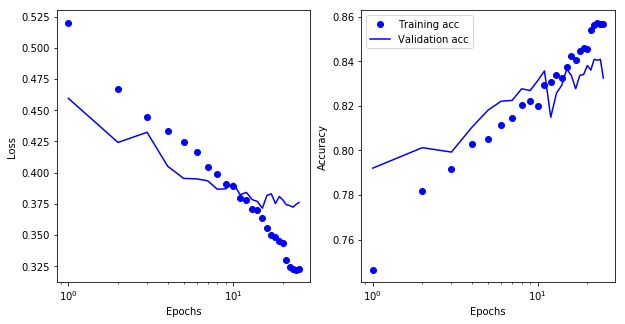

In [40]:
plot_history(history)

In [41]:
roc_auc_score(y_test_vec.values,
              lstm_model.predict(test_vecs.astype('float')).reshape(-1))

0.9294908

In [42]:
with open('data/lstm_hist_32f.pkl','wb') as handle:
    pickle.dump(history.history, handle)

## Same, but with GRU

In [43]:
gru_model = Sequential()
gru_model.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
gru_model.add(Dense(1, activation="sigmoid"))

In [44]:
gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [45]:
history = gru_model.fit(
    train_vecs.astype('float'),
    y_train_vec.values,
    batch_size=64,
    epochs=50,
    validation_split=0.1,
    callbacks=callback_list
)

Train on 22500 samples, validate on 2500 samples
Epoch 1/50
22500/22500 [==============================] - 48s 2ms/sample - loss: 6.9772 - accuracy: 0.6649 - val_loss: 0.6170 - val_accuracy: 0.6576
Epoch 2/50
22500/22500 [==============================] - 46s 2ms/sample - loss: 0.5924 - accuracy: 0.6831 - val_loss: 0.6130 - val_accuracy: 0.6556
Epoch 3/50
22500/22500 [==============================] - 49s 2ms/sample - loss: 0.9121 - accuracy: 0.6800 - val_loss: 0.6142 - val_accuracy: 0.6580
Epoch 4/50
22500/22500 [==============================] - 51s 2ms/sample - loss: 0.6898 - accuracy: 0.6730 - val_loss: 0.6280 - val_accuracy: 0.6480
Epoch 5/50
22500/22500 [==============================] - 52s 2ms/sample - loss: 0.6049 - accuracy: 0.6674 - val_loss: 0.6209 - val_accuracy: 0.6652
Epoch 6/50
22500/22500 [==============================] - 47s 2ms/sample - loss: 0.5958 - accuracy: 0.6760 - val_loss: 0.6175 - val_accuracy: 0.6640
Epoch 7/50
22464/22500 [============================>.] -

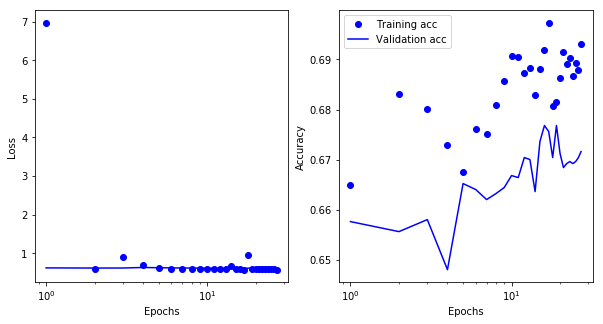

In [46]:
plot_history(history)

In [47]:
roc_auc_score(y_test_vec.values,
              gru_model.predict(test_vecs.astype('float')).reshape(-1))

0.7585095968